In [1]:

import xarray as xr
import pandas as pd
import numpy as np


ds_sat_diff = xr.open_dataset('LGMR_data/ds_sat_diff.nc')
ds_sat_ens_diff= xr.open_dataset('LGMR_data/ds_sat_ens_diff.nc')
ds_sat_ens= xr.open_dataset('LGMR_data/ds_sat_ens_flipped.nc')

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")
df_obl = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\obl.csv")

df_co2_diff = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\co2_diff.csv")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

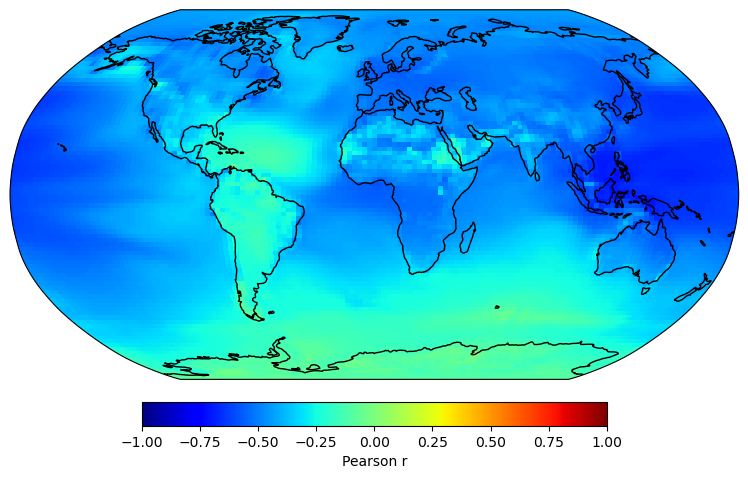

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Extract age, SAT_diff, and precession
age = ds_sat_diff['age'].values
sat = ds_sat_diff['sat_diff'].values  # shape (age, lat, lon)
pre_values = df_pre['pre'].values
pre_age = df_pre['age'].values

# Interpolate precession onto SAT ages
# pre_interp = np.interp(age, pre_age, pre_values)

# Compute Pearson correlation at each grid point
nlat, nlon = ds_sat_diff.sizes["lat"], ds_sat_diff.sizes["lon"]
corr_map = np.full((nlat, nlon), np.nan)

for i in range(nlat):
    for j in range(nlon):
        sat_ts = sat[:, i, j]
        valid = ~np.isnan(sat_ts)
        if valid.sum() > 1:
            corr_map[i, j] = np.corrcoef(sat_ts[valid], pre_values[valid])[0, 1]

# Plot global correlation map
fig=plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
lons = ds_sat_diff['lon'].values
lats = ds_sat_diff['lat'].values
lon2d, lat2d = np.meshgrid(lons, lats)

pcm = ax.pcolormesh(lon2d, lat2d, corr_map,
                    transform=ccrs.PlateCarree(),
                    cmap='jet', vmin=-1, vmax=1)
ax.coastlines()
cb = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.5)
cb.set_label('Pearson r')
# plt.title('Correlation between SAT_diff and Precession')
plt.show()

# save figure as pdf under Figures/
fig.savefig('Figures/corr_map.pdf', format='pdf', bbox_inches='tight')